## Behavior Score calculation - different reward cues session

In [1]:
from ImageAnal import *
%matplotlib inline

#### Load session data


In [2]:
datapath = os.getcwd() + '/' #current working directory - look for data and strings here!
date_time = '2024-09-20_17-18-25' # date and time of the imaging session
name = 'av11' # mouse name
task = 'NearFarLong' # task name

## locate the suite2p folder
suite2p_folder = datapath + 'data/' + name + '_imaging/av11_TSeries_240920-001/'

## the name and location of the imaging log file
imaging_logfile_name = suite2p_folder + 'av11_TSeries_240920-001.xml'

## the name and location of the trigger voltage file
TRIGGER_VOLTAGE_FILENAME = suite2p_folder + 'av11_TSeries_240920-001_Cycle00001_VoltageRecording_001.csv'

In [3]:
D1 = ImagingSessionData(datapath, date_time, name, task, suite2p_folder, imaging_logfile_name, TRIGGER_VOLTAGE_FILENAME)

relevant behavior located, lap time of the first frame: 383.573197
suite2p data loaded
corrected offset: 383.569197000001 voltage_delay: 0.00399999999899592
single-plane
suite2p time axis loaded
calculating dF/F and SNR...
SNR done
dF/F calculated for cell ROI-s
ExpStateMachineLog time interval > 1s:  25  times
length of frame_times: 17925
length of frame_laps: 17925
shape of dF_F: (110, 17925)
############################################################
substage change detected!
first lap in substage  ['2'] is lap 1 , which started at t 16.297310899999502
the time of the change in imaging time is:  -367.2758861000005
############################################################
Late-start lap found, first position: 3567.41 in lap 17 in corridor 25
Early end lap found, last position: 4468.42 in lap 52 in corridor 26
Short lap found, we have total  3653 position bins recorded by the ExpStateMachine in a lap before lap 73 in corridor 26
laps with im data:  [18 19 20 21 22 23 24 25 26 27 2

C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1061: RuntimeWarning: Mean of empty slice
  Fano_factor[i_cell] = np.nanmean(nan_divide(np.nanvar(laps_rates, axis=1), rate_matrix[:,i_cell], rate_matrix[:,i_cell] > 0))
C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1074: RuntimeWarning: invalid value encountered in double_scalars
  skaggs_vector[i_cell] = np.sum(lambda_x[i_nonzero]*np.log2(lambda_x[i_nonzero]/mean_firing)*P_x[i_nonzero]) / mean_firing
C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1117: RuntimeWarning: invalid value encountered in true_divide
  Px = rr / np.sum(rr)
C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\ImageAnal.py:1461: RuntimeWarning: divide by zero encountered in double_scalars
  if ( ( (sum(lapsums > 0.6) / float(N_laps_corr)) > 0.2)  & ( (rate_inField / rate_outField) > 7) ):
C:\Users\martin\home\phd\repos\ABmice_behavScoreIntegration\venv-snezana\lib\site-packages\sc

#### Behavior score calculation

There are three parameters you can set for the function `calculate_behavior_score`:
- corridor A (here it's 25)
- corridor B (here it's 26)
- and the list of laps you want to restrict the calculation to - if you set it to `None` you will calculate it for all the laps

In [4]:
D1.calculate_behavior_score(25, 26)
D1.behavior_table

,P correct (25),P correct (26),Speed index (25),Speed index (26),Speed selectivity,Lick index (25),Lick index (26),Lick selectivity,BEHAVIOR SCORE
0,1.0,1.0,1.022222,1.0,1.056093,0.31,0.05,-0.407142,5.031173


You can save this table into an Excel if you want:


In [5]:
D1.behavior_table.to_excel(suite2p_folder + "behavior_score_table.xlsx", index=False)

#### Behavior plots
- Red bars indicate the pre-RZ and control zones between which lick and speed _indices_ are calculated within each corridor
- Green bars indicate the selectivity zone where speed and lick _selectivities_ are calculated across the two corridors

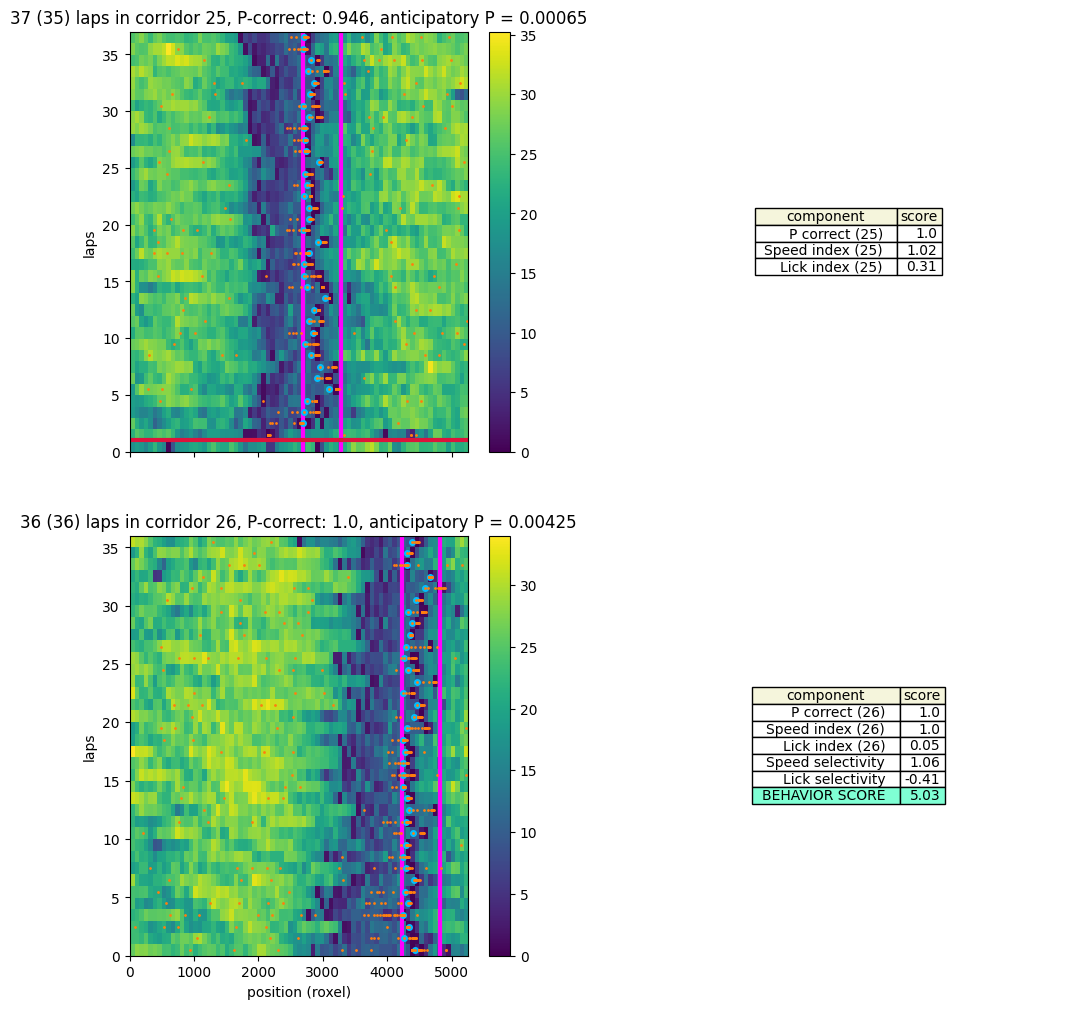

In [6]:
D1.plot_session(average=False)

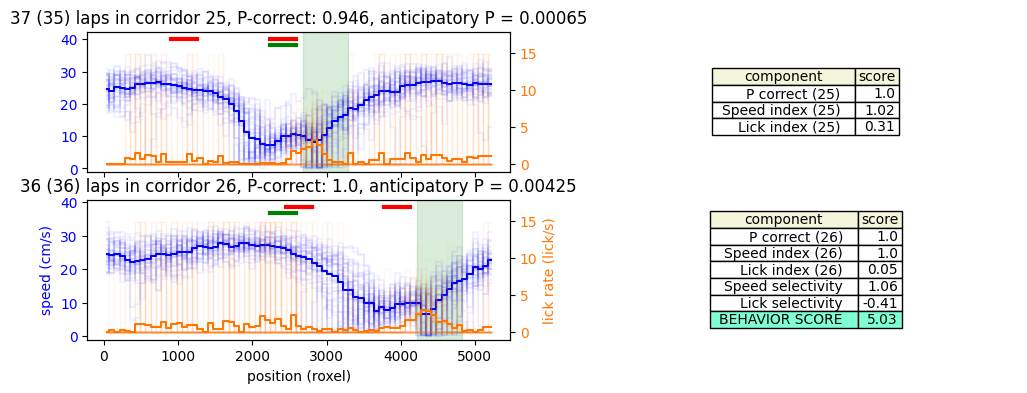

In [7]:
D1.plot_session(average=True)